# ⭐ Day 86: Advanced Computer Vision - Image Classification with CNNs & Transfer Learning
### Day 86 of 369-day Python & AI Learning Path

---

## 🚀 Welcome to Day 86!

Today we enter the thrilling world of **Computer Vision** — one of the most impactful domains in modern AI! 🧠📸

We will build powerful **image classification models** using two complementary approaches:

1. **🧱 Building a CNN from Scratch** — Understanding the fundamentals of convolutional neural networks.
2. **🚀 Transfer Learning with Pre-trained Models** — Leveraging giants like ResNet50, EfficientNet, and VGG16 to achieve state-of-the-art results with less data and training time.

By the end of this notebook, you'll be able to classify images, visualize model decisions with Grad-CAM, and deploy your best model. Let's dive in! 💡

## 📦 Setup & Imports

In [1]:
# Standard libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("\n✅ All libraries imported successfully!")

TensorFlow version: 2.20.0
GPU Available: []

✅ All libraries imported successfully!


## 🧠 Introduction to Computer Vision & Image Classification

**Computer Vision (CV)** is a field of AI that enables computers to derive meaningful information from digital images, videos, and other visual inputs.

### What is Image Classification?
Image classification is the task of assigning a label to an image from a fixed set of categories. It's the foundation of many CV applications including:
- 🏥 Medical imaging diagnosis
- 🚗 Autonomous driving
- 🔒 Facial recognition systems
- 🛒 Visual product search

### Why CNNs?
Convolutional Neural Networks (CNNs) are the de facto architecture for image tasks because they:
- **Preserve spatial structure** through convolution operations
- **Learn hierarchical features** (edges → textures → shapes → objects)
- **Share parameters** via filters, making them efficient

### The Power of Transfer Learning 🚀
Instead of training from scratch, we can use pre-trained models (trained on millions of images like ImageNet) and adapt them to our specific task. This gives us:
- ✅ **Faster convergence**
- ✅ **Better accuracy** with less data
- ✅ **Robust feature extractors** learned from diverse data

## 📸 Loading and Exploring the CIFAR-10 Dataset

We'll use the **CIFAR-10** dataset — a classic benchmark containing 60,000 32×32 color images across 10 classes.

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Number of classes: {len(class_names)}")
print(f"Image shape: {x_train.shape[1:]}")
print(f"Data type: {x_train.dtype}")

# Check class distribution
train_counts = Counter(y_train.flatten())
print("\n📊 Class Distribution in Training Set:")
for i, name in enumerate(class_names):
    print(f"  {name:12s}: {train_counts[i]:5d} images")

Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Number of classes: 10
Image shape: (32, 32, 3)
Data type: uint8

📊 Class Distribution in Training Set:
  airplane    :  5000 images
  automobile  :  5000 images
  bird        :  5000 images
  cat         :  5000 images
  deer        :  5000 images
  dog         :  5000 images
  frog        :  5000 images
  horse       :  5000 images
  ship        :  5000 images
  truck       :  5000 images


C:\Users\786\AppData\Local\Temp\ipykernel_6388\2709271658.py:13: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


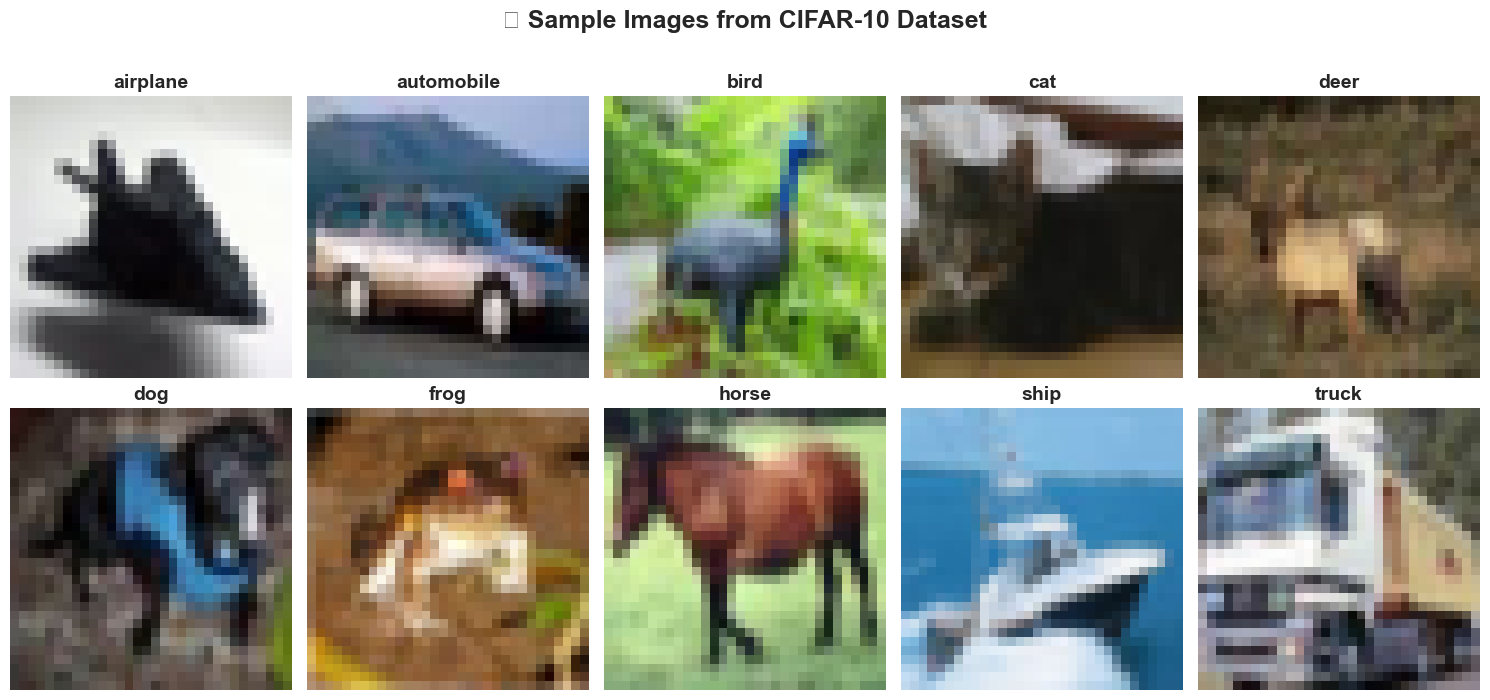


📈 Dataset Statistics:
  Min pixel value: 0
  Max pixel value: 255
  Mean pixel value: 120.71
  Std pixel value: 64.15


In [3]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Find first image of class i
    idx = np.where(y_train.flatten() == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(f"{class_names[i]}", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('📸 Sample Images from CIFAR-10 Dataset', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Display dataset statistics
print("\n📈 Dataset Statistics:")
print(f"  Min pixel value: {x_train.min()}")
print(f"  Max pixel value: {x_train.max()}")
print(f"  Mean pixel value: {x_train.mean():.2f}")
print(f"  Std pixel value: {x_train.std():.2f}")

## 🔧 Data Preprocessing & Augmentation

Proper preprocessing is crucial for CNN performance. We'll:
1. **Normalize pixel values** to [0, 1] range
2. **One-hot encode labels**
3. **Apply data augmentation** to increase diversity and reduce overfitting

In [4]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Split validation set from training data
val_split = 0.1
val_size = int(len(x_train) * val_split)

x_val = x_train[-val_size:]
y_val = y_train_cat[-val_size:]
x_train = x_train[:-val_size]
y_train = y_train_cat[:-val_size]

print(f"Training set:   {x_train.shape[0]} samples")
print(f"Validation set: {x_val.shape[0]} samples")
print(f"Test set:       {x_test.shape[0]} samples")

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

datagen.fit(x_train)
print("\n✅ Data preprocessing and augmentation configured!")

Training set:   45000 samples
Validation set: 5000 samples
Test set:       10000 samples

✅ Data preprocessing and augmentation configured!


C:\Users\786\AppData\Local\Temp\ipykernel_6388\772273538.py:16: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


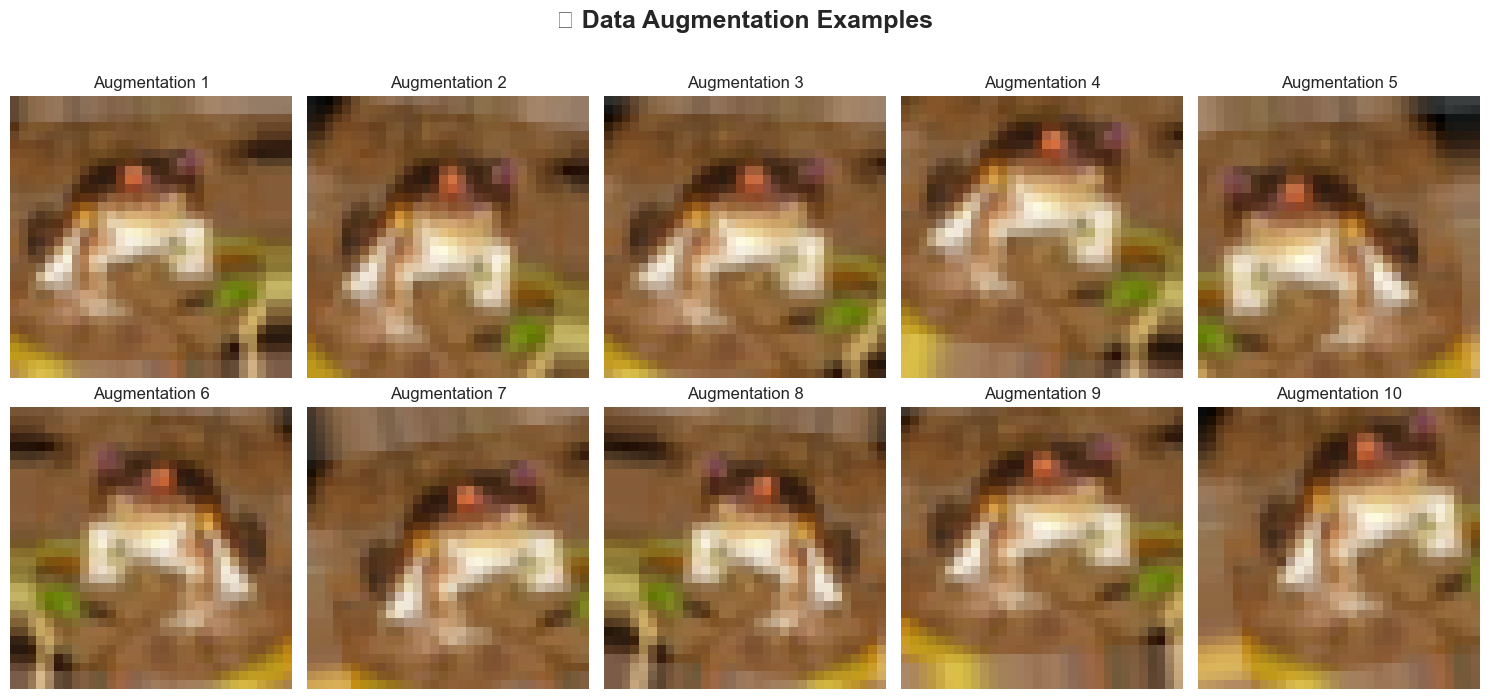

In [5]:
# Visualize augmented images
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

# Generate augmented images from a single sample
sample_img = x_train[0:1]
aug_iter = datagen.flow(sample_img, batch_size=1)

for i, ax in enumerate(axes):
    aug_img = next(aug_iter)[0]
    ax.imshow(aug_img)
    ax.set_title(f"Augmentation {i+1}", fontsize=12)
    ax.axis('off')

plt.suptitle('🎨 Data Augmentation Examples', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🧱 Building a CNN from Scratch

Let's design a custom CNN architecture with the following components:

| Layer Type | Purpose |
|------------|---------|
| **Conv2D** | Extract spatial features using filters |
| **BatchNormalization** | Stabilize and accelerate training |
| **MaxPooling2D** | Reduce spatial dimensions, retain important features |
| **Dropout** | Prevent overfitting |
| **GlobalAveragePooling2D** | Reduce parameters before classification |
| **Dense** | Final classification layers |

In [6]:
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10):
    """Build a custom CNN for CIFAR-10 classification."""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Classification head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build and summarize the model
custom_cnn = build_custom_cnn()
custom_cnn.summary()

c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [8]:
# Compile the model
custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    callbacks.ModelCheckpoint('best_custom_cnn.keras', monitor='val_accuracy', save_best_only=True)
]

# Train the model
print("🚀 Training Custom CNN...")
history_cnn = custom_cnn.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)

print("\n✅ Custom CNN training complete!")

🚀 Training Custom CNN...
Epoch 1/50
 99/704 ━━━━━━━━━━━━━━━━━━━━ 4:11 415ms/step - accuracy: 0.2096 - loss: 2.6522

KeyboardInterrupt: 

In [9]:
def plot_training_history(history, title='Training History'):
    """Plot training and validation accuracy/loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o', markersize=4)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s', markersize=4)
    axes[0].set_title(f'{title} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
    axes[1].set_title(f'{title} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_cnn, 'Custom CNN')

NameError: name 'history_cnn' is not defined

In [10]:
# Evaluate on test set
test_loss, test_acc = custom_cnn.evaluate(x_test, y_test_cat, verbose=0)
print(f"📊 Custom CNN Test Accuracy: {test_acc:.4f}")
print(f"📊 Custom CNN Test Loss: {test_loss:.4f}")

# Predictions
y_pred_cnn = custom_cnn.predict(x_test, verbose=0)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true = y_test.flatten()

print(f"\n✅ Custom CNN evaluation complete!")

📊 Custom CNN Test Accuracy: 0.0994
📊 Custom CNN Test Loss: 2.8582


KeyboardInterrupt: 

## 🚀 Transfer Learning with Pre-trained Models

Transfer learning allows us to leverage knowledge from models trained on massive datasets (like ImageNet with 1.2M images). We'll explore three powerful architectures:

### 🏗️ Model Architectures

| Model | Year | Key Innovation | Parameters |
|-------|------|---------------|------------|
| **VGG16** | 2014 | Deep, simple, uniform 3×3 convolutions | 138M |
| **ResNet50** | 2015 | Skip connections (residual learning) | 25.6M |
| **EfficientNetB0** | 2019 | Compound scaling (depth, width, resolution) | 5.3M |

### Strategy: Feature Extraction + Fine-tuning
1. **Phase 1**: Freeze base model, train only the classification head
2. **Phase 2**: Unfreeze top layers and fine-tune with a low learning rate

### 🎯 Transfer Learning with ResNet50

In [ ]:
def build_transfer_model(base_model_name='ResNet50', input_shape=(32, 32, 3), num_classes=10):
    """Build a transfer learning model with specified base architecture."""
    
    # Select base model
    if base_model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Unknown model: {base_model_name}")
    
    # Freeze base model
    base_model.trainable = False
    
    # Build model
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name=f'{base_model_name}_transfer')
    return model, base_model

# Build ResNet50 transfer model
resnet_model, resnet_base = build_transfer_model('ResNet50')
resnet_model.summary()

In [ ]:
# Phase 1: Train classification head only
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_resnet = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
)

print("🚀 Phase 1: Training ResNet50 classification head...")
history_resnet_phase1 = resnet_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=callbacks_resnet,
    verbose=1
)

print("\n✅ Phase 1 complete!")

### 🔧 Fine-tuning ResNet50

Now we unfreeze the top layers of the base model and continue training with a very low learning rate to avoid catastrophic forgetting.

In [ ]:
# Phase 2: Fine-tuning
# Unfreeze the last 30 layers of ResNet50
resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in resnet_base.layers if l.trainable)} / {len(resnet_base.layers)}")

# Recompile with lower learning rate
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Phase 2: Fine-tuning ResNet50...")
history_resnet_phase2 = resnet_model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=callbacks_resnet,
    verbose=1
)

# Combine histories
for key in history_resnet_phase1.history:
    history_resnet_phase1.history[key].extend(history_resnet_phase2.history[key])

print("\n✅ ResNet50 fine-tuning complete!")

### 🎯 Transfer Learning with VGG16 & EfficientNetB0

Let's quickly train VGG16 and EfficientNetB0 using the same two-phase approach for comparison.

In [ ]:
# VGG16
vgg_model, vgg_base = build_transfer_model('VGG16')
vgg_model.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 Training VGG16...")
history_vgg = vgg_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=callbacks_resnet,
    verbose=1
)

# EfficientNetB0
eff_model, eff_base = build_transfer_model('EfficientNetB0')
eff_model.compile(optimizer=optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("\n🚀 Training EfficientNetB0...")
history_eff = eff_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=callbacks_resnet,
    verbose=1
)

print("\n✅ All transfer learning models trained!")

## 📊 Model Comparison & Performance Analysis

In [ ]:
# Evaluate all models
models_dict = {
    'Custom CNN': custom_cnn,
    'ResNet50': resnet_model,
    'VGG16': vgg_model,
    'EfficientNetB0': eff_model
}

results = {}
for name, model in models_dict.items():
    loss, acc = model.evaluate(x_test, y_test_cat, verbose=0)
    results[name] = {'accuracy': acc, 'loss': loss}
    print(f"{name:20s} -> Accuracy: {acc:.4f} | Loss: {loss:.4f}")

# Plot comparison
names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in names]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.annotate(f'{acc:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Test Accuracy', fontsize=14)
ax.set_title('🏆 Model Performance Comparison on CIFAR-10', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n🏅 Best Model: {best_model_name} with {results[best_model_name]['accuracy']:.4f} accuracy!")

In [ ]:
# Compare training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

histories = {
    'Custom CNN': history_cnn,
    'ResNet50': history_resnet_phase1,
    'VGG16': history_vgg,
    'EfficientNetB0': history_eff
}

for idx, (name, hist) in enumerate(histories.items()):
    ax = axes[idx // 2, idx % 2]
    
    ax.plot(hist.history['accuracy'], label='Train', linewidth=2)
    ax.plot(hist.history['val_accuracy'], label='Val', linewidth=2)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('📈 Training Curves Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔍 Confusion Matrix & Classification Report

In [ ]:
# Use the best model for detailed analysis
best_model = models_dict[best_model_name]
y_pred_best = best_model.predict(x_test, verbose=0)
y_pred_best_classes = np.argmax(y_pred_best, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_best_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 10}, linewidths=0.5)
plt.title(f'🔍 Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print(f"\n📋 Classification Report - {best_model_name}:\n")
print(classification_report(y_true, y_pred_best_classes, target_names=class_names, digits=4))

In [ ]:
# Visualize predictions
def visualize_predictions(model, x_data, y_true, class_names, n_samples=16):
    """Visualize model predictions with confidence scores."""
    y_pred = model.predict(x_data[:n_samples], verbose=0)
    
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        img = x_data[i]
        true_label = class_names[y_true[i]]
        pred_label = class_names[np.argmax(y_pred[i])]
        confidence = np.max(y_pred[i])
        
        ax.imshow(img)
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}',
                    fontsize=10, color=color, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle(f'🎯 Predictions - {best_model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_predictions(best_model, x_test, y_true, class_names)

## 🌡️ Grad-CAM: Visualizing What the Model Sees

**Grad-CAM (Gradient-weighted Class Activation Mapping)** highlights the regions of the image that the model focuses on when making predictions. It's a powerful tool for model interpretability!

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap for an image."""
    grad_model = keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    """Overlay heatmap on original image."""
    heatmap = np.uint8(255 * heatmap)
    jet = plt.cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)
    
    superimposed_img = jet_heatmap * alpha + img * 255
    superimposed_img = keras.utils.array_to_img(superimposed_img)
    
    return superimposed_img

# For ResNet50, use 'conv5_block3_out' as last conv layer
# For custom CNN, use the last conv layer name

# Visualize Grad-CAM for a few test images
if best_model_name == 'ResNet50':
    last_conv = 'conv5_block3_out'
elif best_model_name == 'VGG16':
    last_conv = 'block5_conv3'
elif best_model_name == 'EfficientNetB0':
    last_conv = 'top_conv'
else:
    last_conv = None  # Skip for custom CNN

if last_conv:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i in range(4):
        img = x_test[i]
        img_array = np.expand_dims(img, axis=0)
        
        heatmap = make_gradcam_heatmap(img_array, best_model, last_conv)
        superimposed = display_gradcam(img, heatmap)
        
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Original: {class_names[y_true[i]]}', fontsize=11)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(superimposed)
        pred = class_names[y_pred_best_classes[i]]
        axes[1, i].set_title(f'Grad-CAM: {pred}', fontsize=11)
        axes[1, i].axis('off')
    
    plt.suptitle(f'🌡️ Grad-CAM Visualizations - {best_model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Grad-CAM visualization skipped for custom CNN. Try with a transfer learning model!")

## 💾 Saving the Best Model

In [ ]:
# Save the best model
safe_name = best_model_name.lower().replace(' ', '_')
best_model_path = f'best_model_{safe_name}.keras'
best_model.save(best_model_path)

# Save class names for inference
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print(f"💾 Best model saved to: {best_model_path}")
print(f"📋 Class names saved to: class_names.json")

# Verify saved model
loaded_model = keras.models.load_model(best_model_path)
loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=0)[1]
print(f"\n✅ Loaded model test accuracy: {loaded_acc:.4f}")

# Model size info
model_size = os.path.getsize(best_model_path) / (1024 * 1024)
print(f"📦 Model file size: {model_size:.2f} MB")

In [ ]:
# Quick inference example
def predict_single_image(model, img, class_names):
    """Predict class for a single image."""
    img_batch = np.expand_dims(img, axis=0)
    predictions = model.predict(img_batch, verbose=0)[0]
    
    top_3_idx = np.argsort(predictions)[-3:][::-1]
    top_3 = [(class_names[i], predictions[i]) for i in top_3_idx]
    
    return top_3

# Test on a random image
test_idx = np.random.randint(0, len(x_test))
test_img = x_test[test_idx]
true_class = class_names[y_true[test_idx]]

predictions = predict_single_image(loaded_model, test_img, class_names)

plt.figure(figsize=(8, 6))
plt.imshow(test_img)
plt.title(f'True: {true_class}\nTop Predictions:\n' + '\n'.join([f"{c}: {p:.3f}" for c, p in predictions]),
            fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\n🎯 True class: {true_class}")
print("Top 3 predictions:")
for cls, prob in predictions:
    print(f"  {cls:12s}: {prob:.4f}")

## 🛠️ Hands-On Exercises

Put your skills to the test with these practical challenges! 💪

### Exercise 1: Deeper Architecture 🏗️
Modify the custom CNN to have 4 convolutional blocks instead of 3. Add an additional block with 256 filters and observe if test accuracy improves. Report your findings.

### Exercise 2: Different Dataset 🐱🐶
Replace CIFAR-10 with the **CIFAR-100** dataset (100 fine-grained classes). Build a transfer learning model using EfficientNetB0 and achieve at least 50% top-1 accuracy on the test set.

### Exercise 3: Custom Data Augmentation 🎨
Implement a custom data augmentation pipeline using `tf.image` operations (random brightness, contrast, saturation, and cutout). Compare its performance against the standard `ImageDataGenerator` approach.

### Exercise 4: Ensemble Methods 🤝
Create an ensemble of the best 3 models (e.g., ResNet50 + EfficientNetB0 + Custom CNN). Use soft voting (average probabilities) to make predictions. Compare the ensemble accuracy against individual models.

## ✅ Solutions

Here are complete code solutions for each exercise. Study them carefully and adapt them to your needs!

### ✅ Solution 1: Deeper Architecture

In [ ]:
# Solution 1: Deeper CNN with 4 blocks
def build_deeper_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4 (NEW)
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Classification head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# deeper_cnn = build_deeper_cnn()
# deeper_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# history_deeper = deeper_cnn.fit(datagen.flow(x_train, y_train, batch_size=64),
#                                 epochs=50, validation_data=(x_val, y_val))
print("✅ Solution 1 code ready! Uncomment to run.")

### ✅ Solution 2: CIFAR-100 with EfficientNetB0

In [ ]:
# Solution 2: CIFAR-100 Classification
# (x_train100, y_train100), (x_test100, y_test100) = keras.datasets.cifar100.load_data()

# x_train100 = x_train100.astype('float32') / 255.0
# x_test100 = x_test100.astype('float32') / 255.0
# y_train100_cat = to_categorical(y_train100, 100)
# y_test100_cat = to_categorical(y_test100, 100)

# # Build EfficientNetB0 for CIFAR-100
# base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# base.trainable = False

# inputs = keras.Input(shape=(32, 32, 3))
# x = base(inputs, training=False)
# x = layers.GlobalAveragePooling2D()(x)
# x = layers.Dense(512, activation='relu')(x)
# x = layers.Dropout(0.5)(x)
# outputs = layers.Dense(100, activation='softmax')(x)
# cifar100_model = keras.Model(inputs, outputs)

# cifar100_model.compile(optimizer=optimizers.Adam(0.001),
#                        loss='categorical_crossentropy', metrics=['accuracy'])
# cifar100_model.fit(x_train100, y_train100_cat, batch_size=64, epochs=30,
#                    validation_split=0.1, callbacks=[callbacks.EarlyStopping(patience=5)])
print("✅ Solution 2 code ready! Uncomment to run.")

### ✅ Solution 3: Custom Data Augmentation

In [ ]:
# Solution 3: Custom Augmentation with tf.image
def custom_augment(image, label):
    """Apply custom augmentations to a single image."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0, 1)
    
    # Cutout (random erasing)
    def random_cutout(img):
        h, w = img.shape[0], img.shape[1]
        cutout_size = 8
        y = tf.random.uniform([], 0, h - cutout_size, dtype=tf.int32)
        x = tf.random.uniform([], 0, w - cutout_size, dtype=tf.int32)
        mask = tf.ones_like(img)
        pad_top = y
        pad_bottom = h - y - cutout_size
        pad_left = x
        pad_right = w - x - cutout_size
        mask = tf.pad(mask[y:y+cutout_size, x:x+cutout_size],
                      [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
        return img * mask
    
    image = tf.cond(tf.random.uniform([]) > 0.5,
                    lambda: random_cutout(image),
                    lambda: image)
    
    return image, label

# Create tf.data pipeline
# train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
# train_ds = train_ds.map(custom_augment, num_parallel_calls=tf.data.AUTOTUNE)
# train_ds = train_ds.batch(64).prefetch(tf.data.AUTOTUNE)

# custom_aug_model = build_custom_cnn()
# custom_aug_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# custom_aug_model.fit(train_ds, epochs=50, validation_data=(x_val, y_val))
print("✅ Solution 3 code ready! Uncomment to run.")

### ✅ Solution 4: Ensemble Methods

In [ ]:
# Solution 4: Ensemble with Soft Voting
def ensemble_predict(models, x_data, weights=None):
    """Ensemble prediction using soft voting."""
    predictions = []
    for model in models:
        preds = model.predict(x_data, verbose=0)
        predictions.append(preds)
    
    predictions = np.array(predictions)
    
    if weights is None:
        weights = np.ones(len(models)) / len(models)
    else:
        weights = np.array(weights) / np.sum(weights)
    
    # Weighted average
    ensemble_preds = np.average(predictions, axis=0, weights=weights)
    return ensemble_preds

# ensemble_models = [resnet_model, eff_model, custom_cnn]
# ensemble_preds = ensemble_predict(ensemble_models, x_test)
# ensemble_acc = accuracy_score(y_true, np.argmax(ensemble_preds, axis=1))
# print(f"Ensemble Accuracy: {ensemble_acc:.4f}")

# # Compare with individual models
# individual_accs = {}
# for name, model in zip(['ResNet50', 'EfficientNet', 'Custom CNN'], ensemble_models):
#     preds = model.predict(x_test, verbose=0)
#     acc = accuracy_score(y_true, np.argmax(preds, axis=1))
#     individual_accs[name] = acc
#     print(f"{name}: {acc:.4f}")
print("✅ Solution 4 code ready! Uncomment to run.")

## 🎉 Day 86 Summary & Congratulations!

You made it through Day 86 of your 369-day AI journey! Here's what you accomplished today:

### ✅ What You Learned
- 🧠 **Fundamentals of Computer Vision** and image classification pipelines
- 🧱 **Built a custom CNN from scratch** with BatchNorm, Dropout, and GlobalAveragePooling
- 🚀 **Mastered Transfer Learning** using ResNet50, VGG16, and EfficientNetB0
- 🔧 **Fine-tuned pre-trained models** with careful learning rate scheduling
- 📊 **Compared multiple architectures** and analyzed their performance
- 🔍 **Visualized predictions** with confusion matrices and classification reports
- 🌡️ **Implemented Grad-CAM** to understand what your model sees
- 💾 **Saved and loaded models** for production deployment

### 🏆 Key Takeaways
| Approach | Best For | Trade-off |
|----------|----------|-----------|
| **Custom CNN** | Learning fundamentals, small datasets | Lower accuracy, full control |
| **Transfer Learning** | Production, limited data | Higher accuracy, less interpretable |
| **Fine-tuning** | Domain-specific tasks | Risk of overfitting, needs care |
| **Ensemble** | Maximum accuracy | Increased inference cost |

### 🚀 What's Next?

**Day 87 Teaser:** Tomorrow we dive into **Object Detection** — where we don't just classify images, but also localize and draw bounding boxes around multiple objects! We'll explore YOLO, SSD, and R-CNN architectures. Get ready to make your computer 'see' the world! 🎯📦

---

> 💡 *'The real voyage of discovery consists not in seeking new landscapes, but in having new eyes.'* — Marcel Proust

**Keep pushing forward. You're 86 days stronger!** 💪🔥